# Practical Statistics for Data Scientists - Chapter 6
## Statistical Machine Learning

This notebook covers non-parametric and ensemble machine learning algorithms including K-Nearest Neighbors (KNN), Decision Trees, Random Forests, Gradient Boosted Decision Trees (XGBoost), hyperparameter tuning, and feature importance analysis.

### Environment Setup and Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---

## 1. K-Nearest Neighbors (KNN)

Classifying samples based on distance in feature space, emphasizing feature standardization to ensure equal scale impact.

In [2]:
# Load housing or loan dataset
loan_data = pd.read_csv('drive/MyDrive/Colab Notebooks/data/loan_data.csv')
predictors = ['payment_inc_ratio', 'dti', 'revol_bal', 'revol_util']
X = loan_data[predictors]
y = (loan_data['outcome'] == 'default').astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit KNN Classifier (k = 20)
knn = KNeighborsClassifier(n_neighbors=20)
knn.fit(X_train_scaled, y_train)
knn_preds = knn.predict(X_test_scaled)

print(f"KNN (k=20) Accuracy: {accuracy_score(y_test, knn_preds):.4f}")
print(f"KNN (k=20) ROC-AUC:  {roc_auc_score(y_test, knn.predict_proba(X_test_scaled)[:, 1]):.4f}")

KNN (k=20) Accuracy: 0.5758
KNN (k=20) ROC-AUC:  0.6062


---

## 2. Decision Trees

Recursive partitioning of data using impurity metrics (Gini Impurity / Entropy).

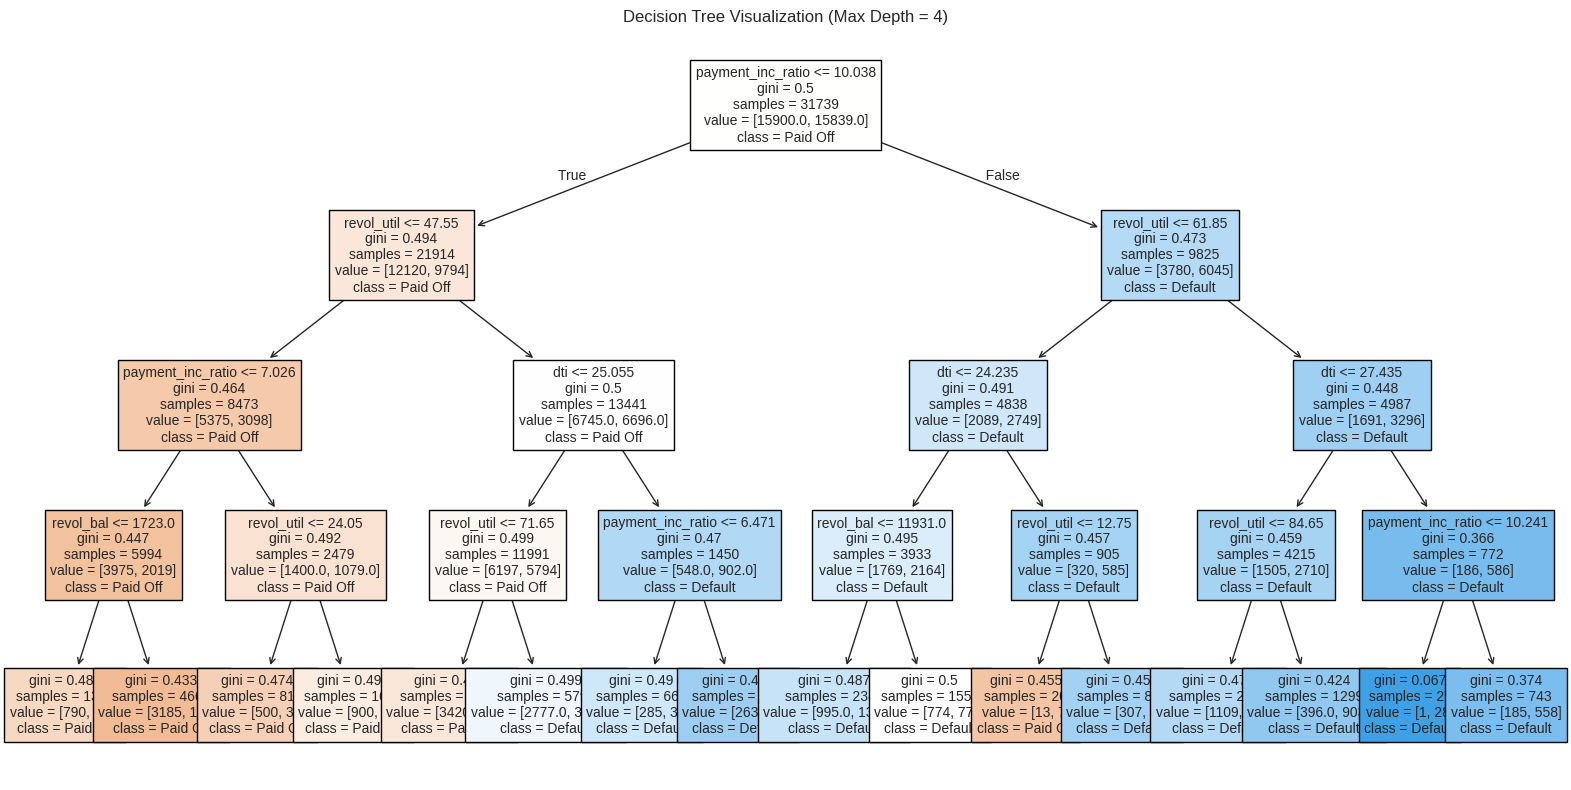

In [3]:
# Fit Single Decision Tree with Depth Control
dtree = DecisionTreeClassifier(max_depth=4, min_samples_split=20, random_state=42)
dtree.fit(X_train, y_train)

# Visualize Tree Decision Nodes
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(dtree, feature_names=predictors, class_names=['Paid Off', 'Default'], filled=True, ax=ax, fontsize=10)
plt.title('Decision Tree Visualization (Max Depth = 4)')
plt.tight_layout()
plt.show()

---

## 3. Random Forests & Feature Importance

Bagging ensemble method combining randomized decision trees to reduce prediction variance.

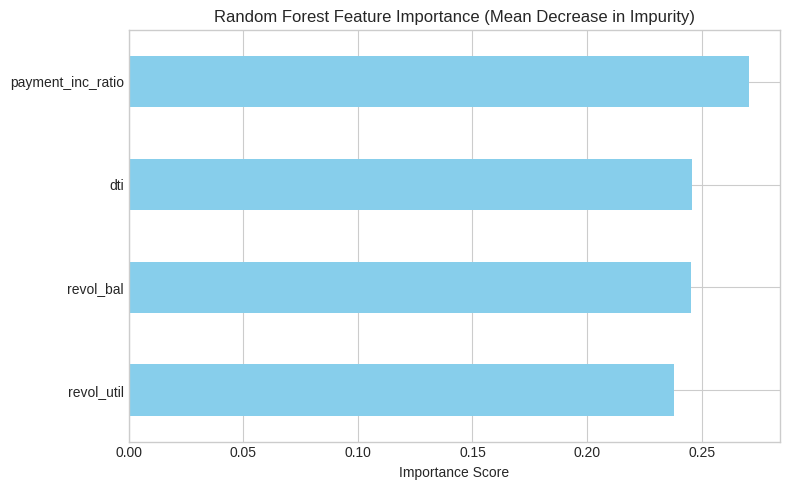

In [4]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=500, max_features='sqrt', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Extract Feature Importances
importances = pd.Series(rf_model.feature_importances_, index=predictors).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='skyblue')
ax.set_title('Random Forest Feature Importance (Mean Decrease in Impurity)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

---

## 4. Gradient Boosted Trees (XGBoost)

Boosting ensemble that sequentially fits weak learners to residual errors of prior iterations.

In [5]:
# Fit XGBoost Classifier
xgb = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)
xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])

print(f"XGBoost Test Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")
print(f"XGBoost Test ROC-AUC:  {xgb_auc:.4f}")

XGBoost Test Accuracy: 0.5969
XGBoost Test ROC-AUC:  0.6399


---

## 5. Hyperparameter Tuning with Grid Search

Systematic optimization of hyperparameters using K-Fold Cross-Validation.

In [6]:
param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=1
)

grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print(f"Best Cross-Validation ROC-AUC: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best Cross-Validation ROC-AUC: 0.6337
